<a href="https://colab.research.google.com/github/CoolSurfer-Samuel/Retail-Sales-Customer-Intelligence-/blob/main/notebooks/%20sales_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv('/content/SuperStoreOrders.csv')

# Show first 5 rows
print(df.head())

          order_id order_date ship_date       ship_mode    customer_name  \
0     AG-2011-2040   1/1/2011  6/1/2011  Standard Class  Toby Braunhardt   
1    IN-2011-47883   1/1/2011  8/1/2011  Standard Class      Joseph Holt   
2     HU-2011-1220   1/1/2011  5/1/2011    Second Class    Annie Thurman   
3  IT-2011-3647632   1/1/2011  5/1/2011    Second Class     Eugene Moren   
4    IN-2011-47883   1/1/2011  8/1/2011  Standard Class      Joseph Holt   

       segment            state    country  market   region  ...  \
0     Consumer      Constantine    Algeria  Africa   Africa  ...   
1     Consumer  New South Wales  Australia    APAC  Oceania  ...   
2     Consumer         Budapest    Hungary    EMEA     EMEA  ...   
3  Home Office        Stockholm     Sweden      EU    North  ...   
4     Consumer  New South Wales  Australia    APAC  Oceania  ...   

          category sub_category                 product_name sales quantity  \
0  Office Supplies      Storage          Tenex Lockers,

In [ ]:
print(df.columns)

Index(['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year'],
      dtype='object')


In [ ]:
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')
df['profit'] = pd.to_numeric(df['profit'], errors='coerce')

In [ ]:
customer_data = df.groupby('customer_name').agg({
    'sales': 'sum',
    'quantity': 'sum',
    'profit': 'sum'
}).reset_index()

print(customer_data.head())

     customer_name    sales  quantity      profit
0    Aaron Bergman  13814.0       301  4683.20800
1    Aaron Hawkins   9171.0       231  2450.92904
2   Aaron Smayling   9675.0       211   369.16180
3  Adam Bellavance   7469.0       262  4979.97690
4        Adam Hart  14637.0       293  1902.03342


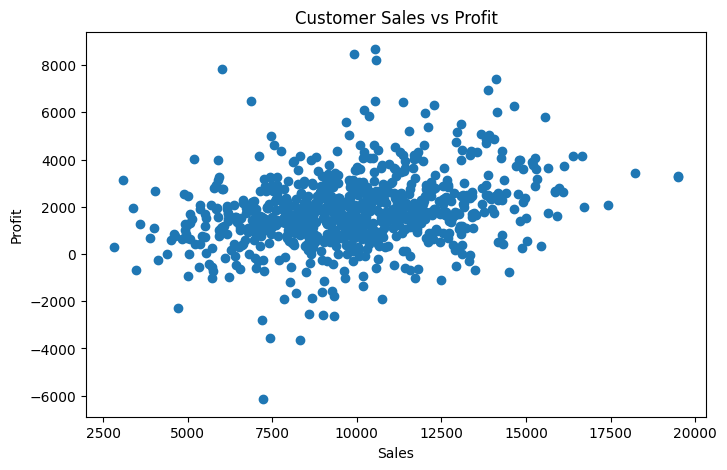

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(customer_data['sales'],
            customer_data['profit'])

plt.xlabel('Sales')
plt.ylabel('Profit')
plt.title('Customer Sales vs Profit')

plt.show()

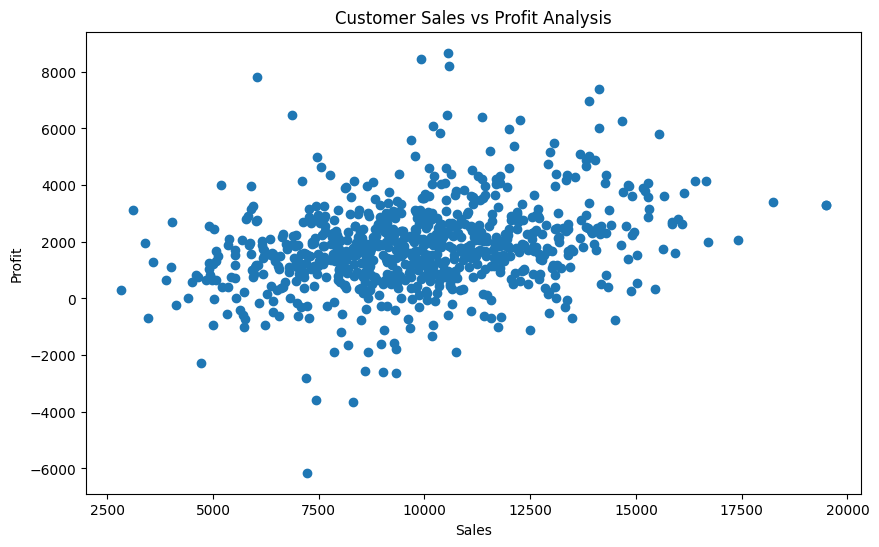

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    customer_data['sales'],
    customer_data['profit']
)

plt.xlabel('Sales')
plt.ylabel('Profit')

plt.title('Customer Sales vs Profit Analysis')

plt.show()

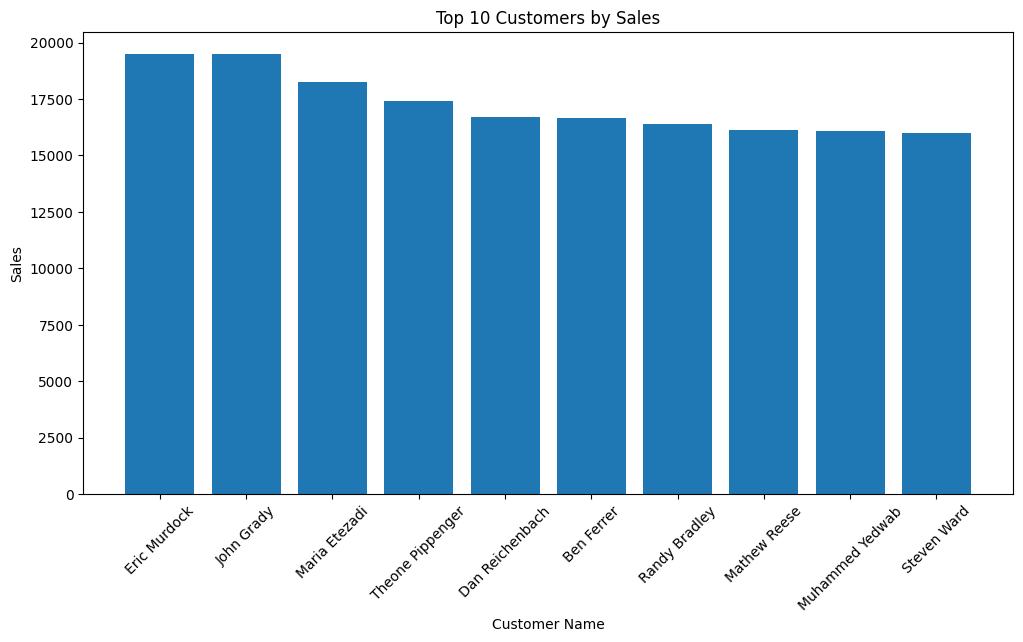

In [ ]:
# Top 10 customers by sales
top_customers = customer_data.sort_values(
    by='sales',
    ascending=False
).head(10)

# Plot bar graph
plt.figure(figsize=(12,6))

plt.bar(
    top_customers['customer_name'],
    top_customers['sales']
)

plt.xlabel('Customer Name')
plt.ylabel('Sales')

plt.title('Top 10 Customers by Sales')

plt.xticks(rotation=45)

plt.show()

In [ ]:
customer_data.to_csv('customer_segmentation.csv', index=False)